In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import datetime
import hashlib
import shutil
import kagglehub
import time  # <-- Adicionado para medir a performance

# ==========================================
# 1. PREPARAÇÃO DO AMBIENTE E DOWNLOAD
# ==========================================
RAW_PATH = 'data/raw'
BRONZE_PATH = 'data/bronze'
SILVER_PATH = 'data/silver'

os.makedirs(RAW_PATH, exist_ok=True)
os.makedirs(BRONZE_PATH, exist_ok=True)
os.makedirs(SILVER_PATH, exist_ok=True)

print("⏳ Baixando dataset do Kaggle...")
path = kagglehub.dataset_download("algozee/cyber-security")

arquivos_raw = ["financial_impact (1).csv", "incidents_master.csv", "market_impact.csv"]

for f in arquivos_raw:
    origem = os.path.join(path, f)
    destino = os.path.join(RAW_PATH, f)

    if os.path.exists(origem):
        shutil.copy(origem, destino)
        print(f"✅ {f} baixado para {RAW_PATH}/")
    else:
        print(f"❌ Arquivo não encontrado: {origem}")

print("\n📂 Arquivos brutos prontos! Iniciando pipeline...\n")


# ==========================================
# 2. INGESTÃO PARA A CAMADA BRONZE
# ==========================================
def gerar_hash(row):
    return hashlib.sha256(str(row).encode()).hexdigest()

print("🚀 Processando e convertendo para Parquet...\n")

# Inicia o cronômetro de alta precisão antes do laço
inicio_processamento = time.perf_counter()

for arquivo in arquivos_raw:
    caminho_input = os.path.join(RAW_PATH, arquivo)

    if os.path.exists(caminho_input):
        df = pd.read_csv(caminho_input)

        # --- ADIÇÃO DE METADADOS ---
        df['meta_file_name'] = arquivo
        df['meta_ingestion_at'] = datetime.datetime.now()
        df['meta_row_count'] = len(df)
        df['meta_row_hash'] = df.apply(gerar_hash, axis=1)

        # Padronização mínima de colunas
        df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

        # --- LIMPEZA DO NOME DO ARQUIVO ---
        nome_limpo = arquivo.replace(" (1)", "")
        nome_saida = nome_limpo.replace('.csv', '_bronze.parquet')
        caminho_output = os.path.join(BRONZE_PATH, nome_saida)

        # Salva na Bronze
        df.to_parquet(caminho_output, index=False)

        print(f"✅ {arquivo} -> {nome_saida} [CONCLUÍDO]")

# Para o cronômetro assim que o laço termina
fim_processamento = time.perf_counter()

# Calcula a diferença e converte para milissegundos
tempo_ms = (fim_processamento - inicio_processamento) * 1000

print("\n🏆 Camada Bronze finalizada com sucesso!")
print(f"⏱️ Tempo total de processamento: {tempo_ms:.2f} ms")

⏳ Baixando dataset do Kaggle...


100%|██████████| 169k/169k [00:00<00:00, 757kB/s]

Extracting files...


✅ financial_impact (1).csv baixado para data/raw/
✅ incidents_master.csv baixado para data/raw/
✅ market_impact.csv baixado para data/raw/

📂 Arquivos brutos prontos! Iniciando pipeline...

🚀 Processando e convertendo para Parquet...

✅ financial_impact (1).csv -> financial_impact_bronze.parquet [CONCLUÍDO]
✅ incidents_master.csv -> incidents_master_bronze.parquet [CONCLUÍDO]
✅ market_impact.csv -> market_impact_bronze.parquet [CONCLUÍDO]

🏆 Camada Bronze finalizada com sucesso!
⏱️ Tempo total de processamento: 1430.60 ms


In [9]:
BRONZE_PATH = 'data/bronze'
arquivos_bronze = [f for f in os.listdir(BRONZE_PATH) if f.endswith('.parquet')]

print("RELATÓRIO DE QUALIDADE - CAMADA BRONZE\n")

for arquivo in arquivos_bronze:
    df = pd.read_parquet(os.path.join(BRONZE_PATH, arquivo))

    print(f"--- Arquivo: {arquivo} ---")
    print(f"Total de Linhas: {len(df)}")

    nulos = df.isnull().sum()
    print("\nCampos com valores nulos (Top 5):")
    print(nulos[nulos > 0].sort_values(ascending=False).head(5))

    if 'incident_id' in df.columns:
        dups = df.duplicated(subset=['incident_id']).sum()
        print(f"\nIDs de incidente duplicados: {dups}")

    cols_data = [col for col in df.columns if 'date' in col or 'at' in col]
    print(f"\nColunas de data detectadas: {cols_data}")

    print("\n" + "="*40 + "\n")

RELATÓRIO DE QUALIDADE - CAMADA BRONZE

--- Arquivo: financial_impact_bronze.parquet ---
Total de Linhas: 778

Campos com valores nulos (Top 5):
ransom_paid_usd        692
ransom_source          692
regulatory_fine_usd    646
ransom_demanded_usd    572
notes                  530
dtype: int64

IDs de incidente duplicados: 0

Colunas de data detectadas: ['regulatory_fine_usd', 'inflation_adjusted_usd', 'created_at', 'updated_at', 'meta_ingestion_at']


--- Arquivo: incidents_master_bronze.parquet ---
Total de Linhas: 850

Campos com valores nulos (Top 5):
review_flag                780
industry_secondary         697
attack_vector_secondary    639
notes                      636
data_source_secondary      464
dtype: int64

IDs de incidente duplicados: 0

Colunas de data detectadas: ['incident_date', 'incident_date_estimated', 'discovery_date', 'disclosure_date', 'attack_vector_primary', 'attack_vector_secondary', 'attack_chain', 'attributed_group', 'attribution_confidence', 'data_compromis

In [10]:
df_incidents = pd.read_parquet('data/bronze/incidents_master_bronze.parquet')
df_financial = pd.read_parquet('data/bronze/financial_impact_bronze.parquet')


df_financial['ransom_paid_usd'] = df_financial['ransom_paid_usd'].fillna(0)
df_financial['regulatory_fine_usd'] = df_financial['regulatory_fine_usd'].fillna(0)


df_incidents['incident_date'] = pd.to_datetime(df_incidents['incident_date'])

df_silver = pd.merge(df_incidents, df_financial, on='incident_id', how='left')

cols_leakage = ['recovery_cost_usd', 'legal_fees_usd', 'notes', 'review_flag', 'downtime_hours']


cols_para_remover = [col for col in cols_leakage if col in df_silver.columns]

df_silver = df_silver.drop(columns=cols_para_remover)

print(f"✅ Colunas removidas: {cols_para_remover}")


import os
os.makedirs('data/silver', exist_ok=True)
df_silver.to_parquet('data/silver/cyber_security_silver.parquet', index=False)

print("Camada Prata gerada com sucesso!")

✅ Colunas removidas: ['recovery_cost_usd', 'legal_fees_usd', 'review_flag', 'downtime_hours']
Camada Prata gerada com sucesso!


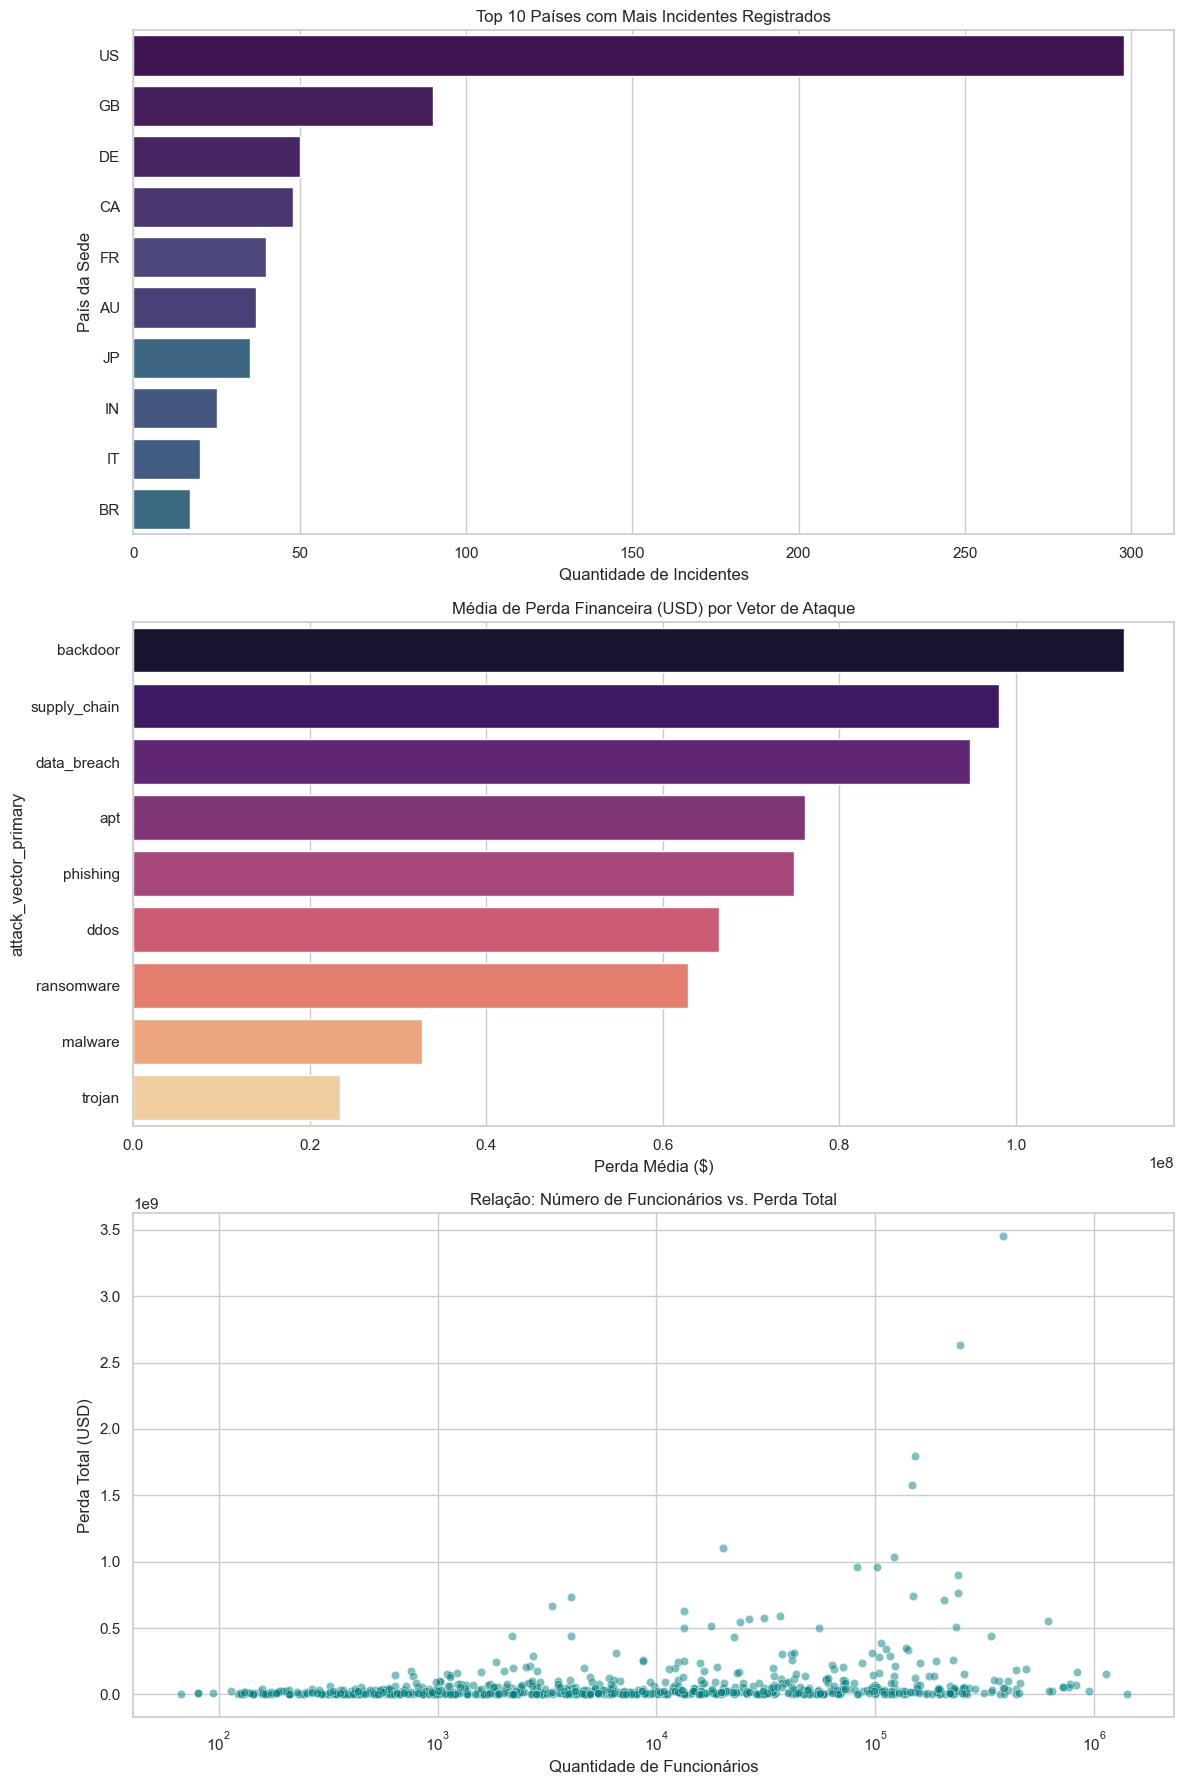

In [11]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.countplot(data=df_silver, y='country_hq', order=df_silver['country_hq'].value_counts().iloc[:10].index, hue='country_hq', palette='viridis', legend=False)
plt.title('Top 10 Países com Mais Incidentes Registrados')
plt.xlabel('Quantidade de Incidentes')
plt.ylabel('País da Sede')

plt.subplot(3, 1, 2)

media_perda = df_silver.groupby('attack_vector_primary')['total_loss_usd'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=media_perda.values, y=media_perda.index, hue=media_perda.index, palette='magma', legend=False)
plt.title('Média de Perda Financeira (USD) por Vetor de Ataque')
plt.xlabel('Perda Média ($)')

plt.subplot(3, 1, 3)
sns.scatterplot(data=df_silver, x='employee_count', y='total_loss_usd', alpha=0.5, color='teal')
plt.title('Relação: Número de Funcionários vs. Perda Total')
plt.xlabel('Quantidade de Funcionários')
plt.ylabel('Perda Total (USD)')
plt.xscale('log')

plt.tight_layout()
plt.show()